# Cebada NIR — Validación anidada y límites de transferencia

Este notebook acompaña el estudio **Grouped Validation of Machine Learning for Moisture Exposure Stage Estimation in Barley Using NIR Spectra**.

Lee resultados terminados del script `run_nested_validation.py`; no presenta la factibilidad como una evaluación independiente. El modo predeterminado no vuelve a entrenar modelos. La recomputación completa es opcional y puede tardar bastante más que la lectura de los resultados.

El objetivo es una **etapa experimental**: 0 = referencia seca anterior a la humectación; 1–5 = adquisiciones diarias posteriores. No se predicen viabilidad, humedad química ni tiempo continuo validado entre adquisiciones. No se procesan imágenes.

Datos: [archivo ERDA de University of Copenhagen](https://doi.org/10.17894/ucph.71c22737-8005-4588-bd74-80bf7b5ac6b4), CC BY-NC 4.0. Informe de origen: [Engstrøm et al.](https://arxiv.org/abs/2504.16658).

In [1]:
from pathlib import Path
import hashlib
import importlib.util
import json
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold

try:
    from IPython.display import display, Image
except ImportError:
    def display(value):
        print(value.to_string(index=False) if isinstance(value, pd.DataFrame) else value)
    def Image(filename):
        return f'Figura: {filename}'

try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = Path('/content/drive/MyDrive/CITI2027_CEBADA_NIR')
except ImportError:
    local_roots = [Path.cwd(), Path.cwd().parent]
    PROJECT_DIR = next((root for root in local_roots
                        if (root / '01_DATASET' / 'barley_nir_long.npz').exists()
                        or (root / 'project_artifacts' / 'barley_nir_long.npz').exists()), Path.cwd())

DATA_FILE = PROJECT_DIR / '01_DATASET' / 'barley_nir_long.npz'
RESULTS_DIR = PROJECT_DIR / '03_RESULTADOS'
CODE_FILE = PROJECT_DIR / '02_CODIGO_NOTEBOOKS' / 'run_nested_validation.py'
if not DATA_FILE.exists() and (PROJECT_DIR / 'project_artifacts' / 'barley_nir_long.npz').exists():
    DATA_FILE = PROJECT_DIR / 'project_artifacts' / 'barley_nir_long.npz'
    RESULTS_DIR = PROJECT_DIR / 'project_artifacts'
    CODE_FILE = PROJECT_DIR / 'run_nested_validation.py'
assert DATA_FILE.exists(), f'Dataset no encontrado: {DATA_FILE}'
print('Proyecto:', PROJECT_DIR)
print('Resultados:', RESULTS_DIR)

Proyecto: /workspace/scratch/02bbe1088ac9
Resultados: /workspace/scratch/02bbe1088ac9/project_artifacts


## 1 Auditoría del dataset

Se comprueba la clave placa–grano–etapa y la cobertura de las seis adquisiciones. Los cuatro grupos muestrales no son cuatro cultivares. La diferencia de 381 frente a 382 eventos en la tabla agregada del informe original no modifica este objetivo; las anotaciones de germinación no entran en los predictores.

Solo se debe cargar el NPZ de esta fuente conocida, porque contiene metadatos de texto serializados.

In [2]:
z = np.load(DATA_FILE, allow_pickle=True)
X = z['X']
y = z['day'].astype(int)
dish = z['petri_dish'].astype(int)
grain = z['grain_id'].astype(int)
grain_uid = np.array([f'{d}_{g}' for d, g in zip(dish, grain)])
meta = pd.DataFrame({'grain_uid': grain_uid, 'petri_dish': dish,
                     'stage': y, 'sample_group': z['sample_group'].astype(str),
                     'cultivar': z['cultivar'].astype(str)})
assert X.shape == (13452, 204) and np.isfinite(X).all()
assert meta['grain_uid'].nunique() == 2242 and meta['petri_dish'].nunique() == 90
assert not meta.duplicated(['grain_uid', 'stage']).any()
assert meta.groupby('grain_uid')['stage'].nunique().eq(6).all()
assert meta.groupby('petri_dish')['sample_group'].nunique().eq(1).all()
display(meta.loc[meta.stage.eq(0)].groupby(['cultivar', 'sample_group'])
        .agg(kernels=('grain_uid', 'nunique'), dishes=('petri_dish', 'nunique')).reset_index())
print('Etapas:', np.unique(y).tolist(), '| Auditoría estructural: OK')

cultivar sample_group  kernels  dishes
Laureate   laureate_0      624      25
Laureate   laureate_1      600      24
Prospect   prospect_0      624      25
Prospect   prospect_1      394      16
Etapas: [0, 1, 2, 3, 4, 5] | Auditoría estructural: OK


## 2 Diseño y recomputación opcional

Comparación principal: cinco pliegues externos por placa; selección de configuración en cuatro pliegues internos, también por placa. PLSR: 9 configuraciones; SVR RBF: 8; Extra Trees: 6. La estandarización por canal se ajusta dentro de cada entrenamiento. SNV y Savitzky–Golay actúan sobre cada espectro individual.

La factibilidad anterior orientó las rejillas usando este mismo dataset. La validación anidada evita el uso directo del test externo en la selección interna actual, pero no convierte el estudio en una prueba externa intacta ni en un protocolo prerregistrado.

Para entrenar de nuevo, cambie `RUN_FULL_ANALYSIS` a `True` y elija una carpeta inexistente en `FRESH_PROJECT_DIR`. El helper `tools/recompute_project.py` copia datos verificados y scripts, sin resultados ni checkpoints anteriores, y fuerza un nuevo ajuste. También calcula diagnósticos y audita las nuevas predicciones. El archivo publicado se conserva. La corrida completa no fue repetida durante la auditoría de cierre.

In [3]:
RUN_FULL_ANALYSIS = False
FRESH_PROJECT_DIR = PROJECT_DIR.parent / (PROJECT_DIR.name + '_fresh_fit')
if RUN_FULL_ANALYSIS:
    import subprocess
    import sys
    helper = PROJECT_DIR / 'tools' / 'recompute_project.py'
    assert helper.exists(), f'Copie también la carpeta tools del repositorio: {helper}'
    subprocess.run([sys.executable, str(helper), '--destination', str(FRESH_PROJECT_DIR)], check=True)
    PROJECT_DIR = FRESH_PROJECT_DIR
    DATA_FILE = PROJECT_DIR / '01_DATASET' / 'barley_nir_long.npz'
    RESULTS_DIR = PROJECT_DIR / '03_RESULTADOS'
    CODE_FILE = PROJECT_DIR / '02_CODIGO_NOTEBOOKS' / 'run_nested_validation.py'

METADATA_FILE = RESULTS_DIR / 'nested_run_metadata.json'
assert METADATA_FILE.exists(), 'Corrida incompleta: ejecute el script antes de leer resultados.'
run = json.loads(METADATA_FILE.read_text())
assert run['data_sha256'] == hashlib.sha256(DATA_FILE.read_bytes()).hexdigest()
assert run['outer_splits'] == 5 and run['inner_splits'] == 4
assert run['grouping_unit'] == 'petri_dish'
print('Versiones registradas:', run['versions'])
print('Firma de la corrida:', run['run_signature'])
print('Familia seleccionada:', run['best_family'])

Versiones registradas: {'python': '3.12.14', 'numpy': '2.3.5', 'pandas': '2.2.3', 'scipy': '1.17.0', 'scikit_learn': '1.8.0'}
Firma de la corrida: 2ac6e04bdea67ee7
Familia seleccionada: SVR_RBF


In [4]:
oof = pd.read_csv(RESULTS_DIR / 'nested_oof_predictions.csv.gz')
folds = pd.read_csv(RESULTS_DIR / 'nested_outer_fold_metrics.csv')
assert set(oof.family) == {'PLSR', 'SVR_RBF', 'ExtraTrees'}
assert len(folds) == 15
fold_of_row = np.empty(len(y), dtype=int)
audit_rows = []
for fold, (train_idx, test_idx) in enumerate(GroupKFold(5).split(X, y, dish), 1):
    assert set(dish[train_idx]).isdisjoint(dish[test_idx])
    fold_of_row[test_idx] = fold
    audit_rows.append({'fold': fold, 'train_dishes': len(np.unique(dish[train_idx])),
                       'test_dishes': len(np.unique(dish[test_idx])),
                       'test_observations': len(test_idx)})
for family, frame in oof.groupby('family'):
    assert len(frame) == len(y) and frame.row_index.nunique() == len(y)
    idx = frame.row_index.to_numpy(dtype=int)
    assert np.array_equal(frame.y_true.to_numpy(), y[idx])
    assert np.array_equal(frame.petri_dish.to_numpy(), dish[idx])
    assert np.array_equal(frame.outer_fold.to_numpy(), fold_of_row[idx])
    assert np.isfinite(frame.y_pred).all()
display(pd.DataFrame(audit_rows))
print('Cada observación tiene una única predicción externa por familia. Placas disjuntas: OK.')

 fold  train_dishes  test_dishes  test_observations
    1            72           18               2694
    2            72           18               2694
    3            72           18               2688
    4            72           18               2688
    5            72           18               2688
Cada observación tiene una única predicción externa por familia. Placas disjuntas: OK.


## 3 Comparación principal e incertidumbre condicional

La tabla presenta métricas agrupadas de todas las predicciones externas; son diferentes de la media no ponderada de cinco métricas de pliegue. Los intervalos remuestrean las 90 placas con reemplazo 2.000 veces sobre errores OOF fijos. No se reajustan modelos en el bootstrap ni se remuestrean sesiones independientes. Los contrastes usan las mismas extracciones de placas para cada familia y son condicionales a los procedimientos evaluados.

In [5]:
ci = pd.read_csv(RESULTS_DIR / 'nested_cluster_bootstrap_ci.csv')
summary = ci.pivot(index='family', columns='metric', values='estimate')
mae_ci = ci.loc[ci.metric.eq('mae')].set_index('family')[['ci_low', 'ci_high']]
display(summary.join(mae_ci).sort_values('mae').reset_index().round(4))
display(pd.read_csv(RESULTS_DIR / 'nested_model_summary.csv').round(4))
display(pd.read_csv(RESULTS_DIR / 'nested_paired_mae_differences.csv').round(4))
display(pd.read_csv(RESULTS_DIR / 'nested_selection_frequency.csv'))

    family    bias    mae     r2   rmse  within_1_day  ci_low  ci_high
   SVR_RBF -0.0153 0.5770 0.7806 0.7999        0.8026  0.5602   0.5944
      PLSR -0.0010 0.7218 0.7218 0.9008        0.7246  0.7051   0.7382
ExtraTrees  0.0030 0.8558 0.5624 1.1297        0.6169  0.8383   0.8729
    family  mae_mean  mae_sd  rmse_mean  rmse_sd  r2_mean  r2_sd  within_1_day_mean  bias_mean
   SVR_RBF    0.5770  0.0102     0.7999   0.0127   0.7806 0.0070             0.8026    -0.0153
      PLSR    0.7218  0.0137     0.9006   0.0217   0.7218 0.0135             0.7246    -0.0010
ExtraTrees    0.8558  0.0176     1.1295   0.0261   0.5624 0.0202             0.6169     0.0029
              comparison  mae_difference_days  ci_low  ci_high
ExtraTrees minus SVR_RBF               0.2789  0.2645   0.2924
      PLSR minus SVR_RBF               0.1448  0.1304   0.1582
    family preprocessing                         parameter  outer_folds_selected
ExtraTrees           raw max_features=1;min_samples_leaf=2        

Figura: /workspace/scratch/02bbe1088ac9/project_artifacts/fig_nested_model_comparison.png
Figura: /workspace/scratch/02bbe1088ac9/project_artifacts/fig_best_observed_vs_predicted.png


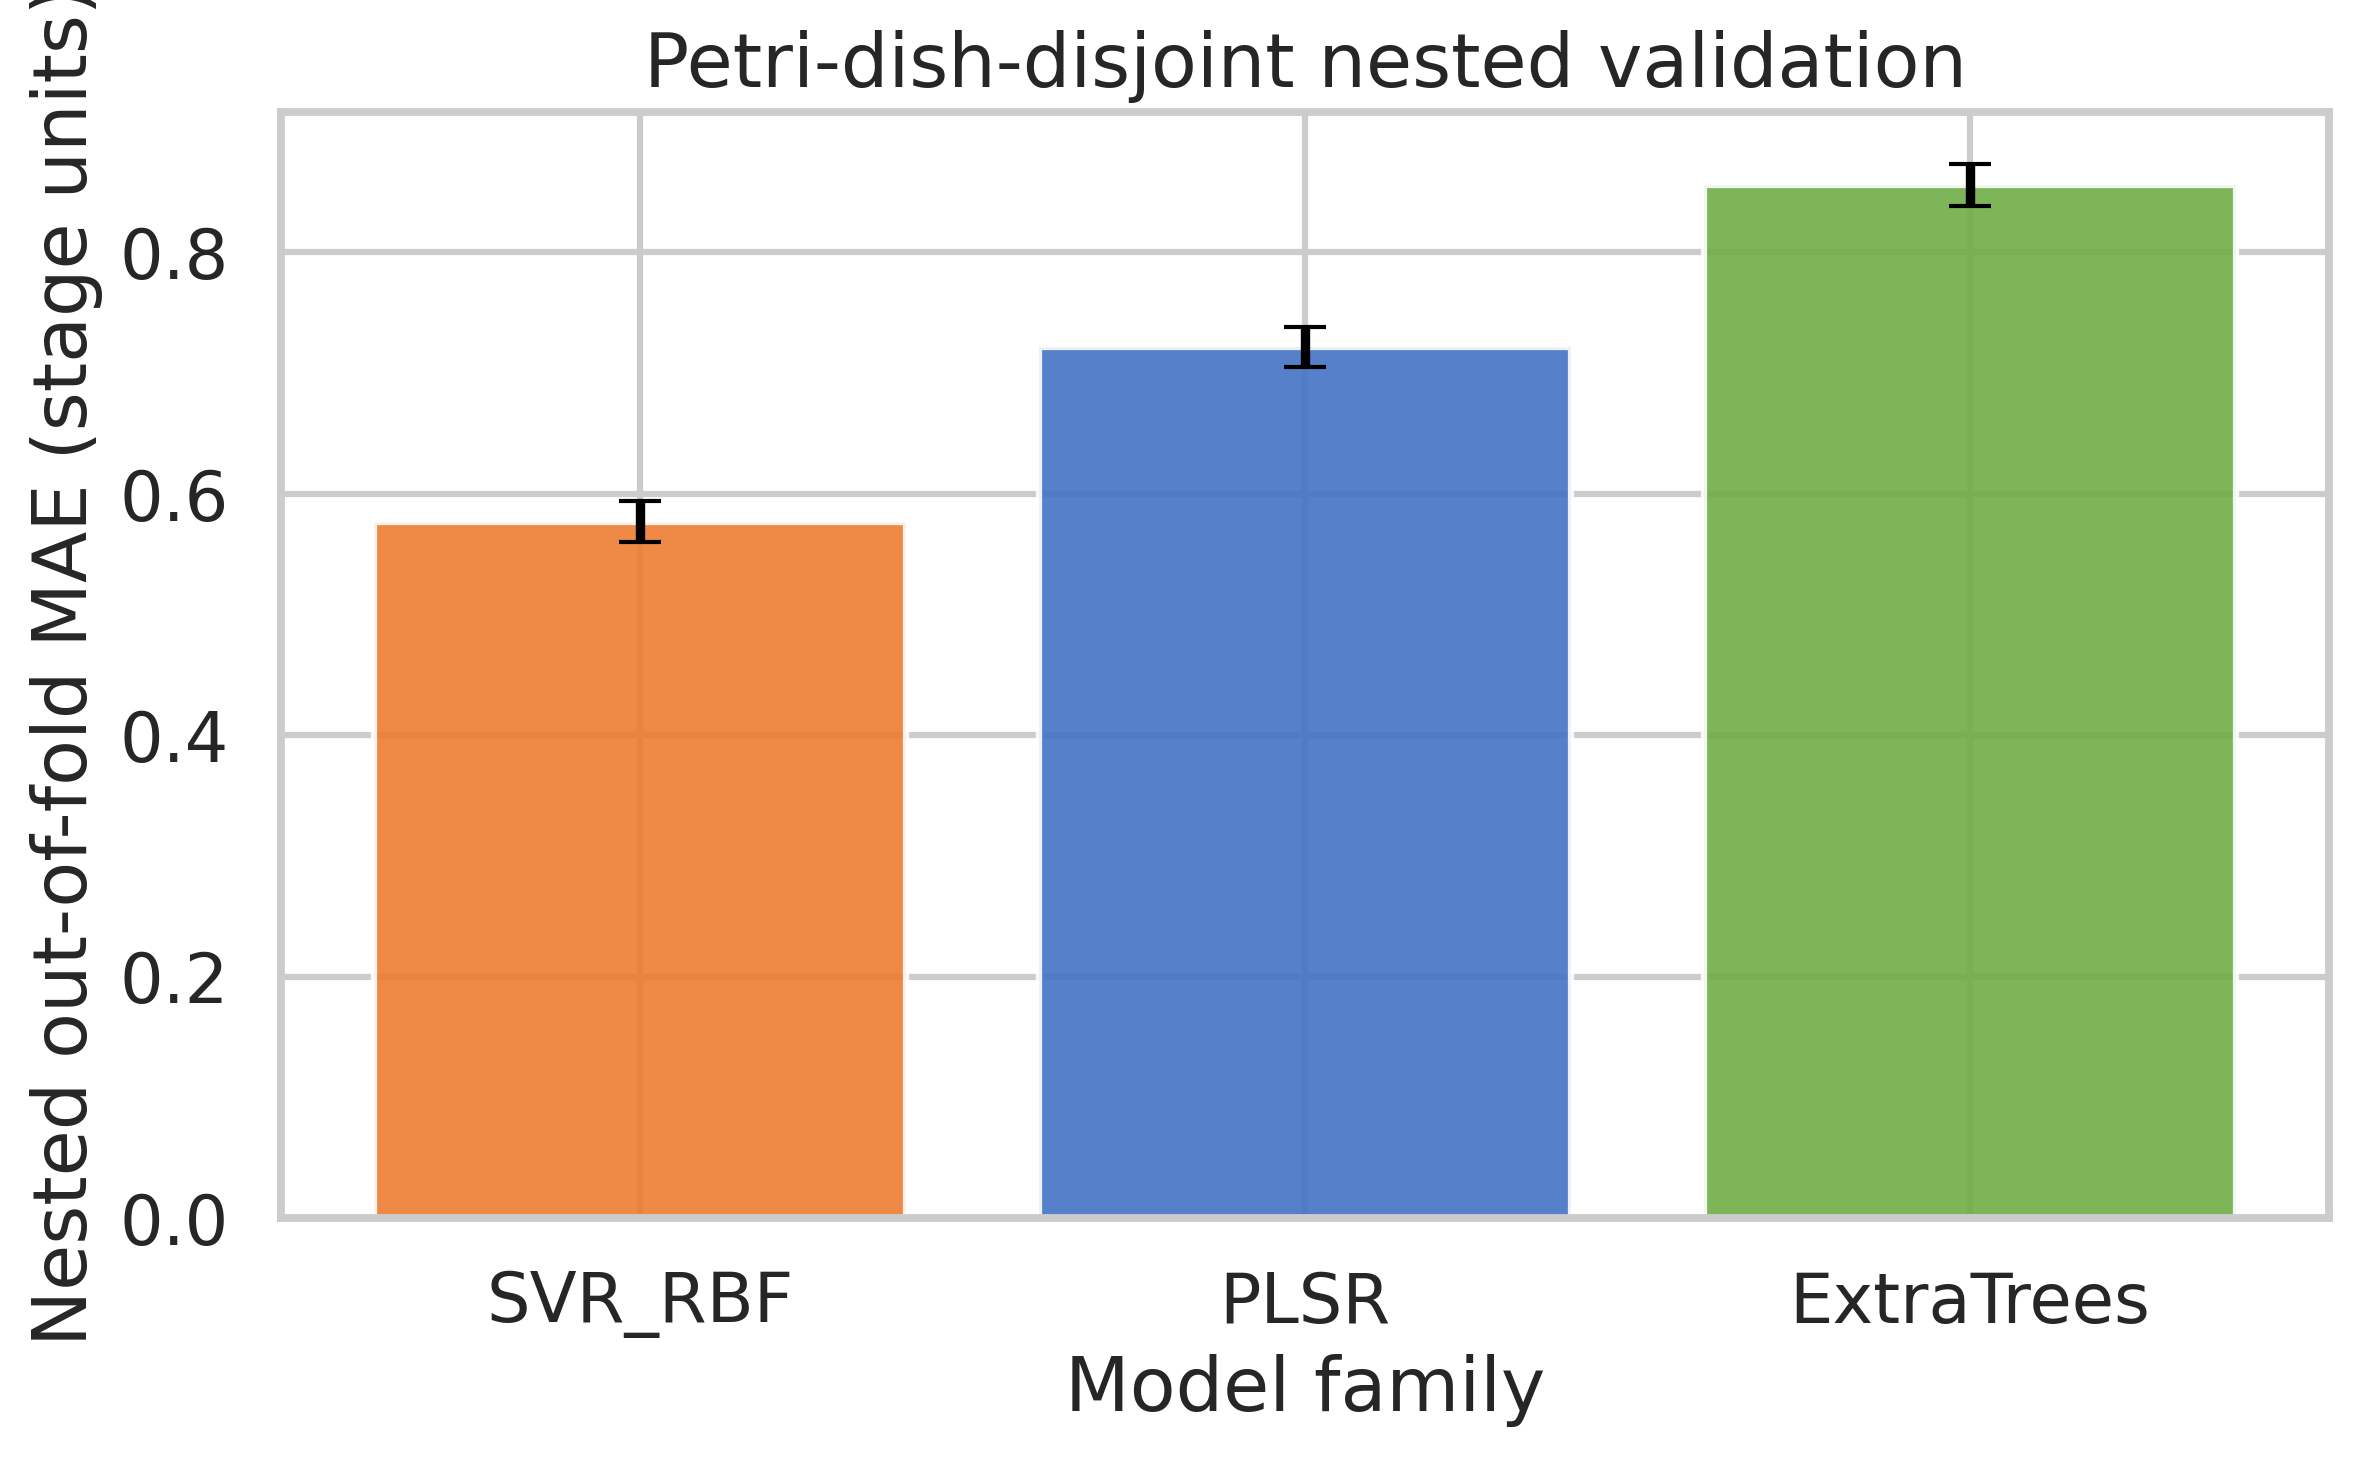

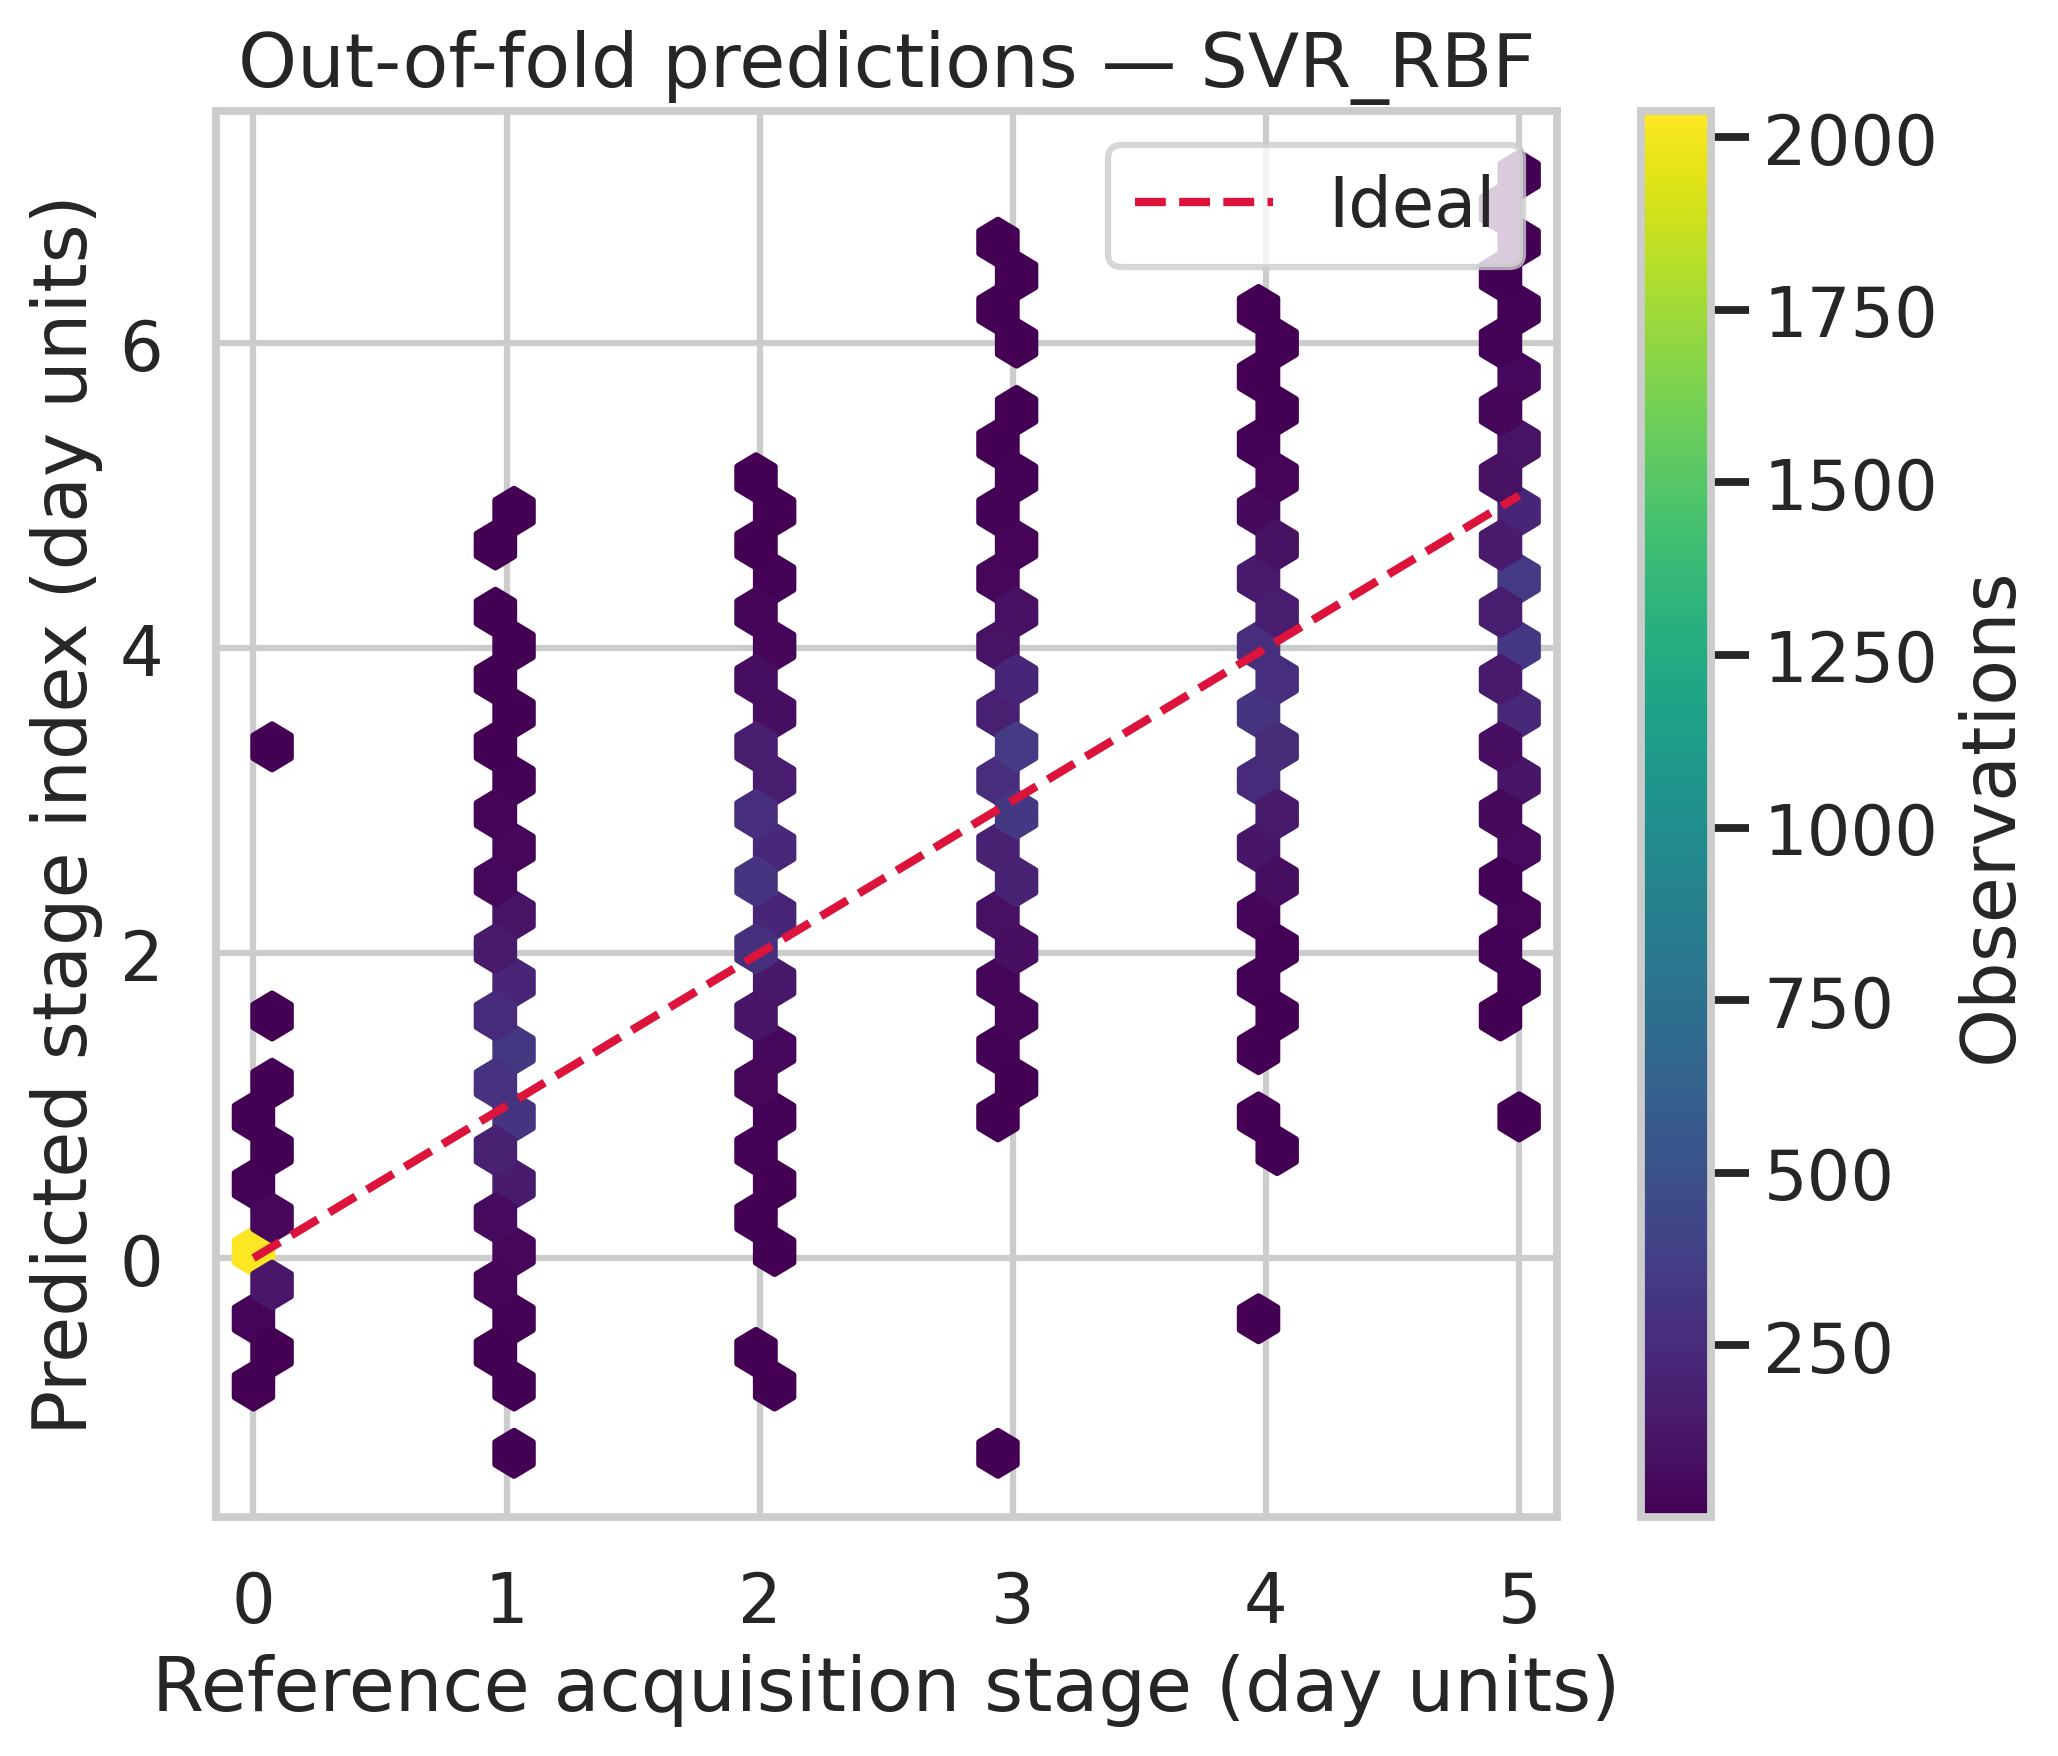

In [6]:
display(Image(filename=str(RESULTS_DIR / 'fig_nested_model_comparison.png')))
display(Image(filename=str(RESULTS_DIR / 'fig_best_observed_vs_predicted.png')))

## 4 Perfil por etapa y referencia seca

Se mantienen las predicciones continuas sin redondear ni recortar. Estar dentro de ±1 etapa no equivale a exactitud de clasificación. La comparación restringida a etapas 1–5 usa las mismas predicciones externas del modelo entrenado con las seis etapas: no es un modelo nuevo ni una prueba independiente.

              subset            predictor   mae   rmse     r2  within_1_stage
      all_six_stages              SVR_RBF 0.577 0.7999 0.7806          0.8026
      all_six_stages constant_subset_mean 1.500 1.7078 0.0000          0.3333
post_moisture_1_to_5              SVR_RBF 0.680 0.8745 0.6176          0.7634
post_moisture_1_to_5 constant_subset_mean 1.200 1.4142 0.0000          0.6000
 day_since_moisture    n    mae   rmse    bias  within_1_day
                0.0 2242 0.0618 0.1248  0.0062        0.9982
                1.0 2242 0.5682 0.7483  0.3193        0.8359
                2.0 2242 0.7341 0.9222  0.5789        0.7230
                3.0 2242 0.5482 0.7083  0.1750        0.8568
                4.0 2242 0.6143 0.7723 -0.3616        0.8113
                5.0 2242 0.9352 1.1469 -0.8097        0.5901
Figura: /workspace/scratch/02bbe1088ac9/project_artifacts/fig_best_error_by_day.png


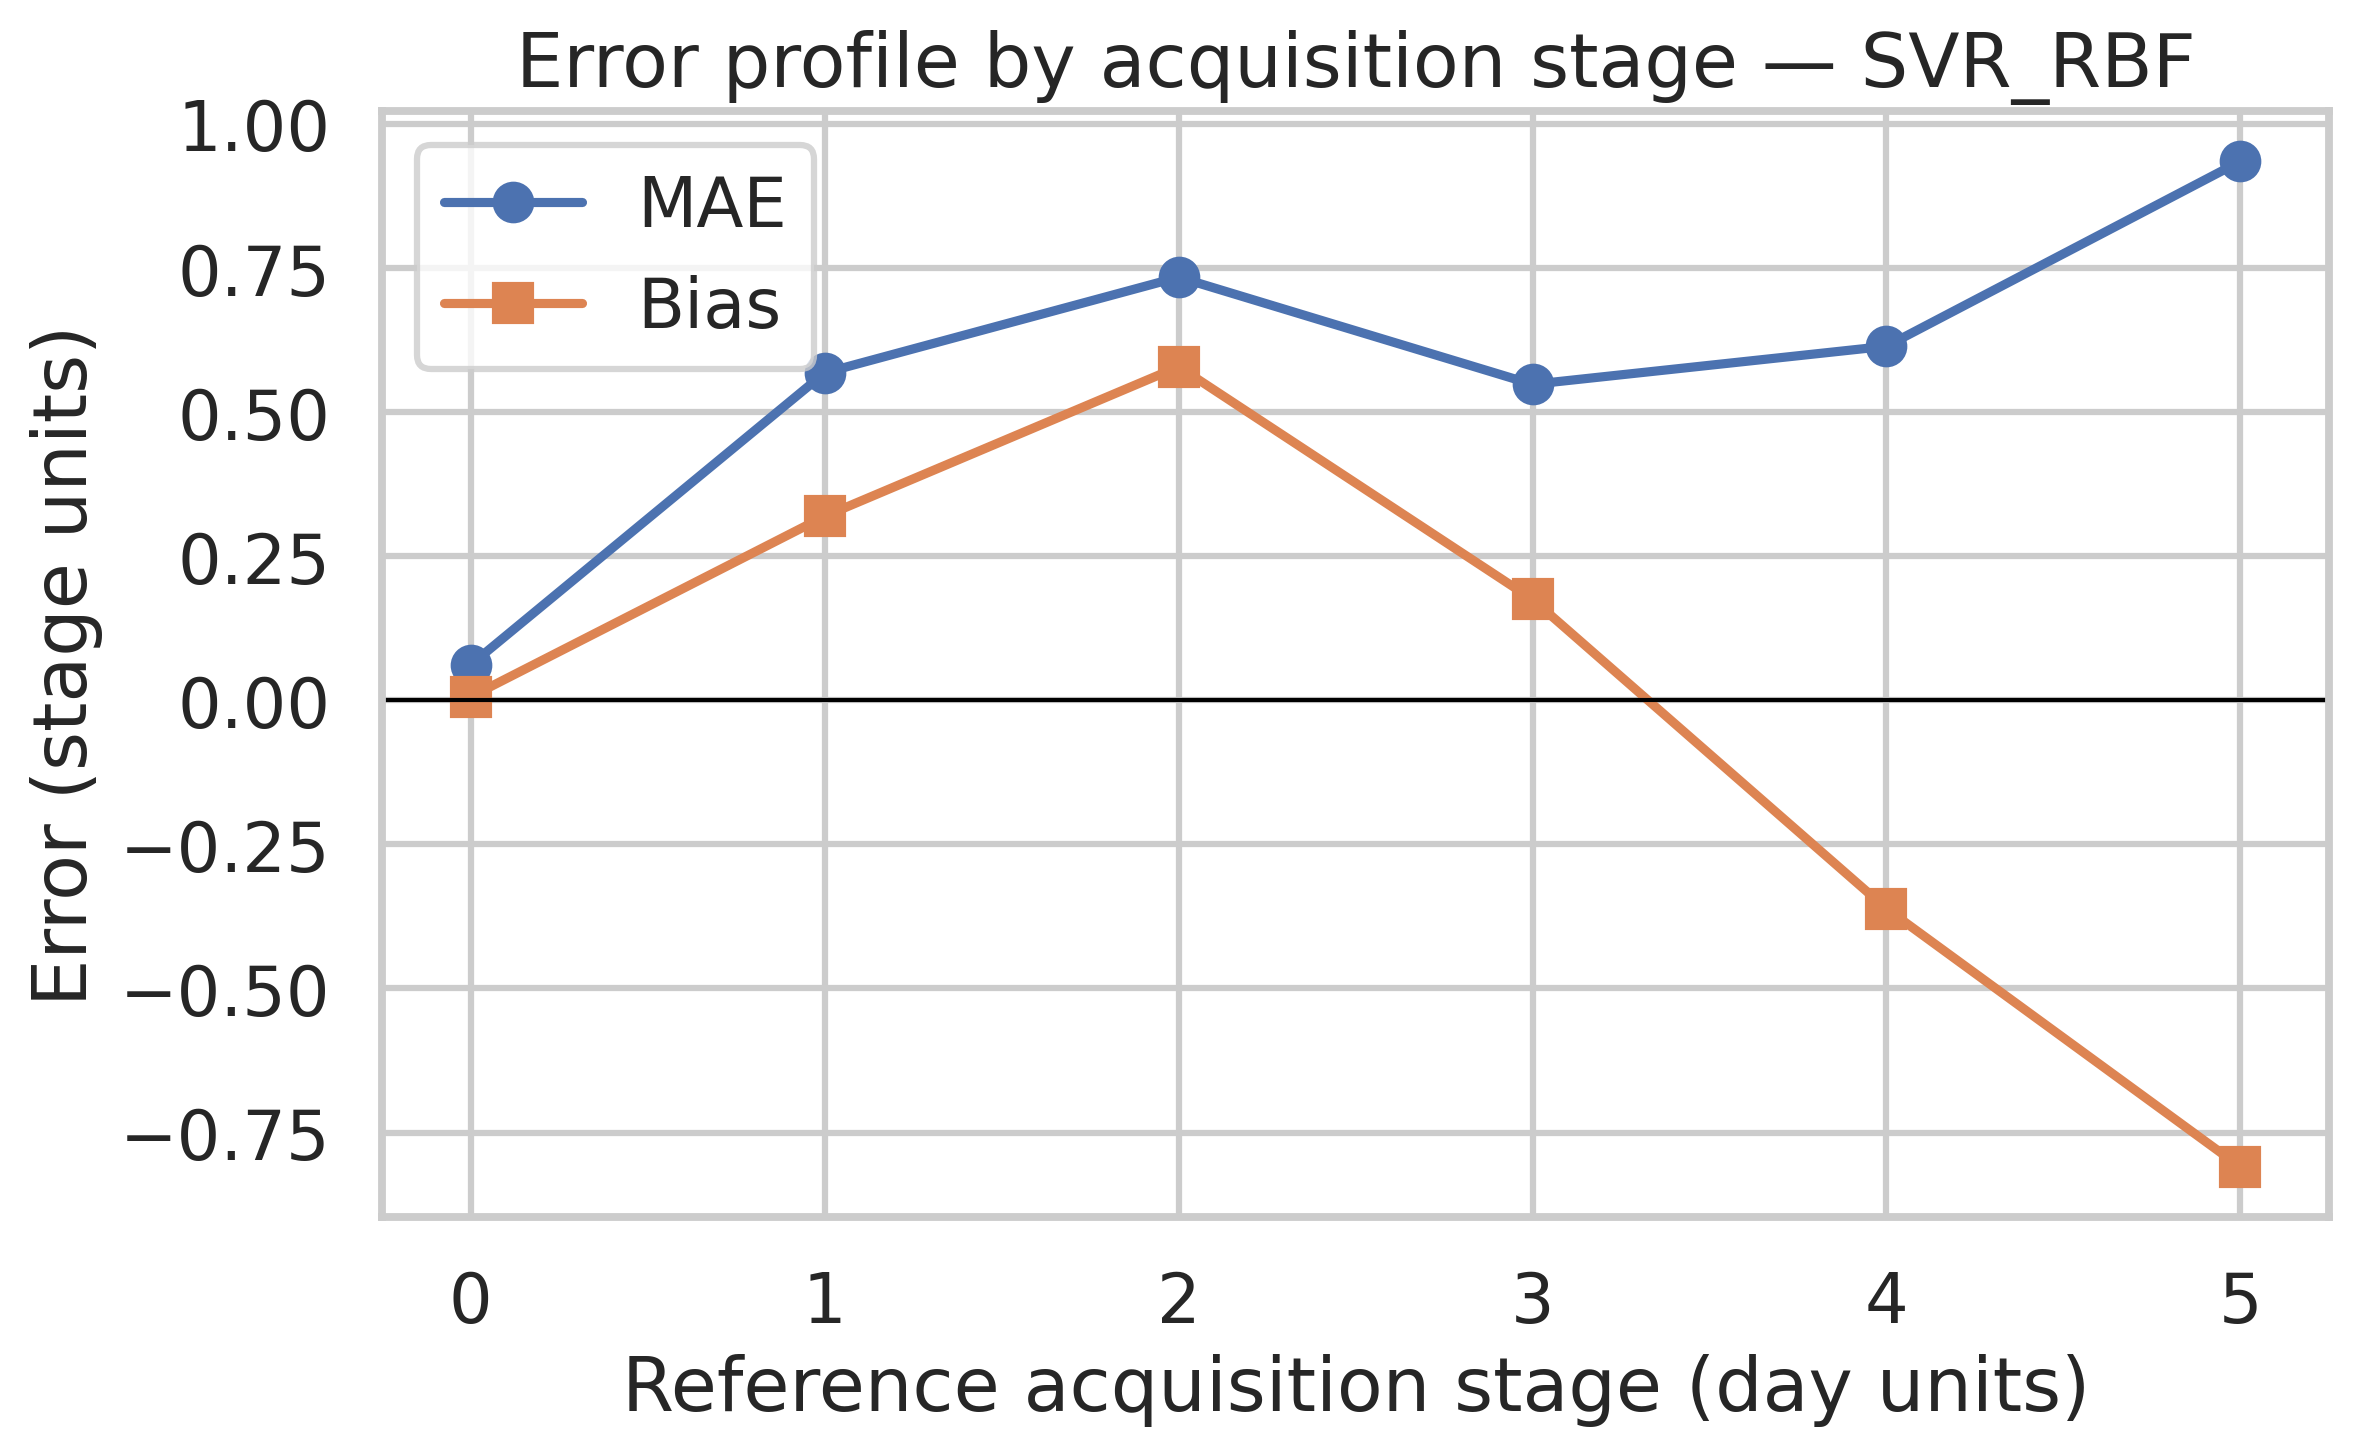

In [7]:
best = oof.loc[oof.family.eq(run['best_family'])]
def metrics(frame, prediction):
    truth = frame.y_true.to_numpy()
    return {'mae': mean_absolute_error(truth, prediction),
            'rmse': np.sqrt(mean_squared_error(truth, prediction)),
            'r2': r2_score(truth, prediction),
            'within_1_stage': np.mean(np.abs(truth - prediction) <= 1)}
rows = []
for label, frame in [('all_six_stages', best), ('post_moisture_1_to_5', best.loc[best.y_true.ge(1)])]:
    rows.append({'subset': label, 'predictor': run['best_family'], **metrics(frame, frame.y_pred)})
    rows.append({'subset': label, 'predictor': 'constant_subset_mean',
                 **metrics(frame, np.full(len(frame), frame.y_true.mean()))})
display(pd.DataFrame(rows).round(4))
display(pd.read_csv(RESULTS_DIR / 'best_model_metrics_by_day.csv').round(4))
display(Image(filename=str(RESULTS_DIR / 'fig_best_error_by_day.png')))

## 5 Sensibilidad a la partición y transferencia exploratoria

La sensibilidad fila–grano–placa mantiene fija la configuración de consenso de la familia ganadora. No vuelve a seleccionar hiperparámetros en cada esquema y no reemplaza la estimación anidada.

Las pruebas que retienen un cultivar o un grupo completo vuelven a seleccionar configuración únicamente con las placas de entrenamiento. La familia, en cambio, se eligió en la comparación principal; estas pruebas son exploratorias a ese nivel. No se deben mezclar las seis direcciones en una supuesta exactitud poblacional universal.

In [8]:
display(pd.read_csv(RESULTS_DIR / 'split_sensitivity_summary.csv').round(4))
stress = pd.read_csv(RESULTS_DIR / 'domain_stress_test_summary.csv')
display(stress[['scheme', 'held_out', 'preprocessing', 'parameter', 'mae', 'rmse', 'r2',
                'within_1_day', 'n_train_dishes', 'n_test_dishes']].round(4))
for _, row in stress.iterrows():
    values = meta.cultivar if row.scheme == 'leave_one_cultivar_out' else meta.sample_group
    assert set(meta.loc[values.ne(row.held_out), 'petri_dish']).isdisjoint(
        set(meta.loc[values.eq(row.held_out), 'petri_dish']))
print('Las pruebas de transferencia mantienen placas completas fuera del entrenamiento.')

        scheme    mae   rmse     r2  within_1_day    bias
    random_row 0.5545 0.7637 0.8000        0.8144 -0.0152
grain_disjoint 0.5632 0.7778 0.7925        0.8138 -0.0170
 dish_disjoint 0.5752 0.7964 0.7825        0.8040 -0.0173
                    scheme   held_out preprocessing                      parameter    mae   rmse     r2  within_1_day  n_train_dishes  n_test_dishes
    leave_one_cultivar_out   Laureate     savgol_d1 C=100;epsilon=0.05;gamma=scale 0.6670 0.8992 0.7228        0.7451              41             49
    leave_one_cultivar_out   Prospect           snv C=100;epsilon=0.05;gamma=scale 0.8153 1.1516 0.5453        0.6994              49             41
leave_one_sample_group_out laureate_0           snv C=100;epsilon=0.05;gamma=scale 0.6670 0.8939 0.7260        0.7366              65             25
leave_one_sample_group_out laureate_1     savgol_d1 C=100;epsilon=0.05;gamma=scale 0.6139 0.8249 0.7667        0.7758              66             24
leave_one_sample_group_

## 6 Interpretación espectral y sensibilidad congelada de C

Los perfiles VIP y coeficientes explican PLS, no directamente SVR. Se calculan únicamente con los entrenamientos externos. Las curvas post-humedad reutilizan el número de componentes seleccionado con las seis etapas y son exploratorias; no se atribuye desempeño a un modelo nuevo de etapas 1–5. El eje 950–1650 nm es una aproximación uniforme documentada en el README, no una calibración exacta.

En la ventana aproximada 1400–1500 nm, los VIP medios son inferiores a uno y la mayoría de canales no supera ese umbral descriptivo: no se respalda afirmar que la banda del agua domine PLS. El pico medio separa claramente la referencia seca y disminuye de la etapa 1 a la 5; no demuestra aumento monótono de concentración de agua. La sensibilidad congelada empeora MAE al aumentar C; no se selecciona un nuevo modelo por sus errores externos.

C=300 y C=1000 se comparan manteniendo las particiones, el preprocesamiento y epsilon originales de cada fold. Las predicciones C=100 son las guardadas en la comparación principal. No se elige un nuevo C mirando errores externos ni se sobrescriben las predicciones principales. Para recomputar estos diagnósticos de forma explícita, cambie solo `RUN_REVIEW_DIAGNOSTICS`.

 outer_fold  train_dishes  test_dishes  dish_overlap  profile_test_observations_used
          1            72           18             0                               0
          2            72           18             0                               0
          3            72           18             0                               0
          4            72           18             0                               0
          5            72           18             0                               0
     training_subset  outer_fold band_nm_approx  n_channels  vip_mean  vip_max  fraction_vip_gt_1  coefficient_abs_mean
      all_six_stages           1      1400-1500          29    0.7737   1.0189             0.0345                8.0637
      all_six_stages           2      1400-1500          29    0.7768   1.0259             0.0345               11.4909
      all_six_stages           3      1400-1500          29    0.7743   1.0261             0.0345                7.9379
      all_

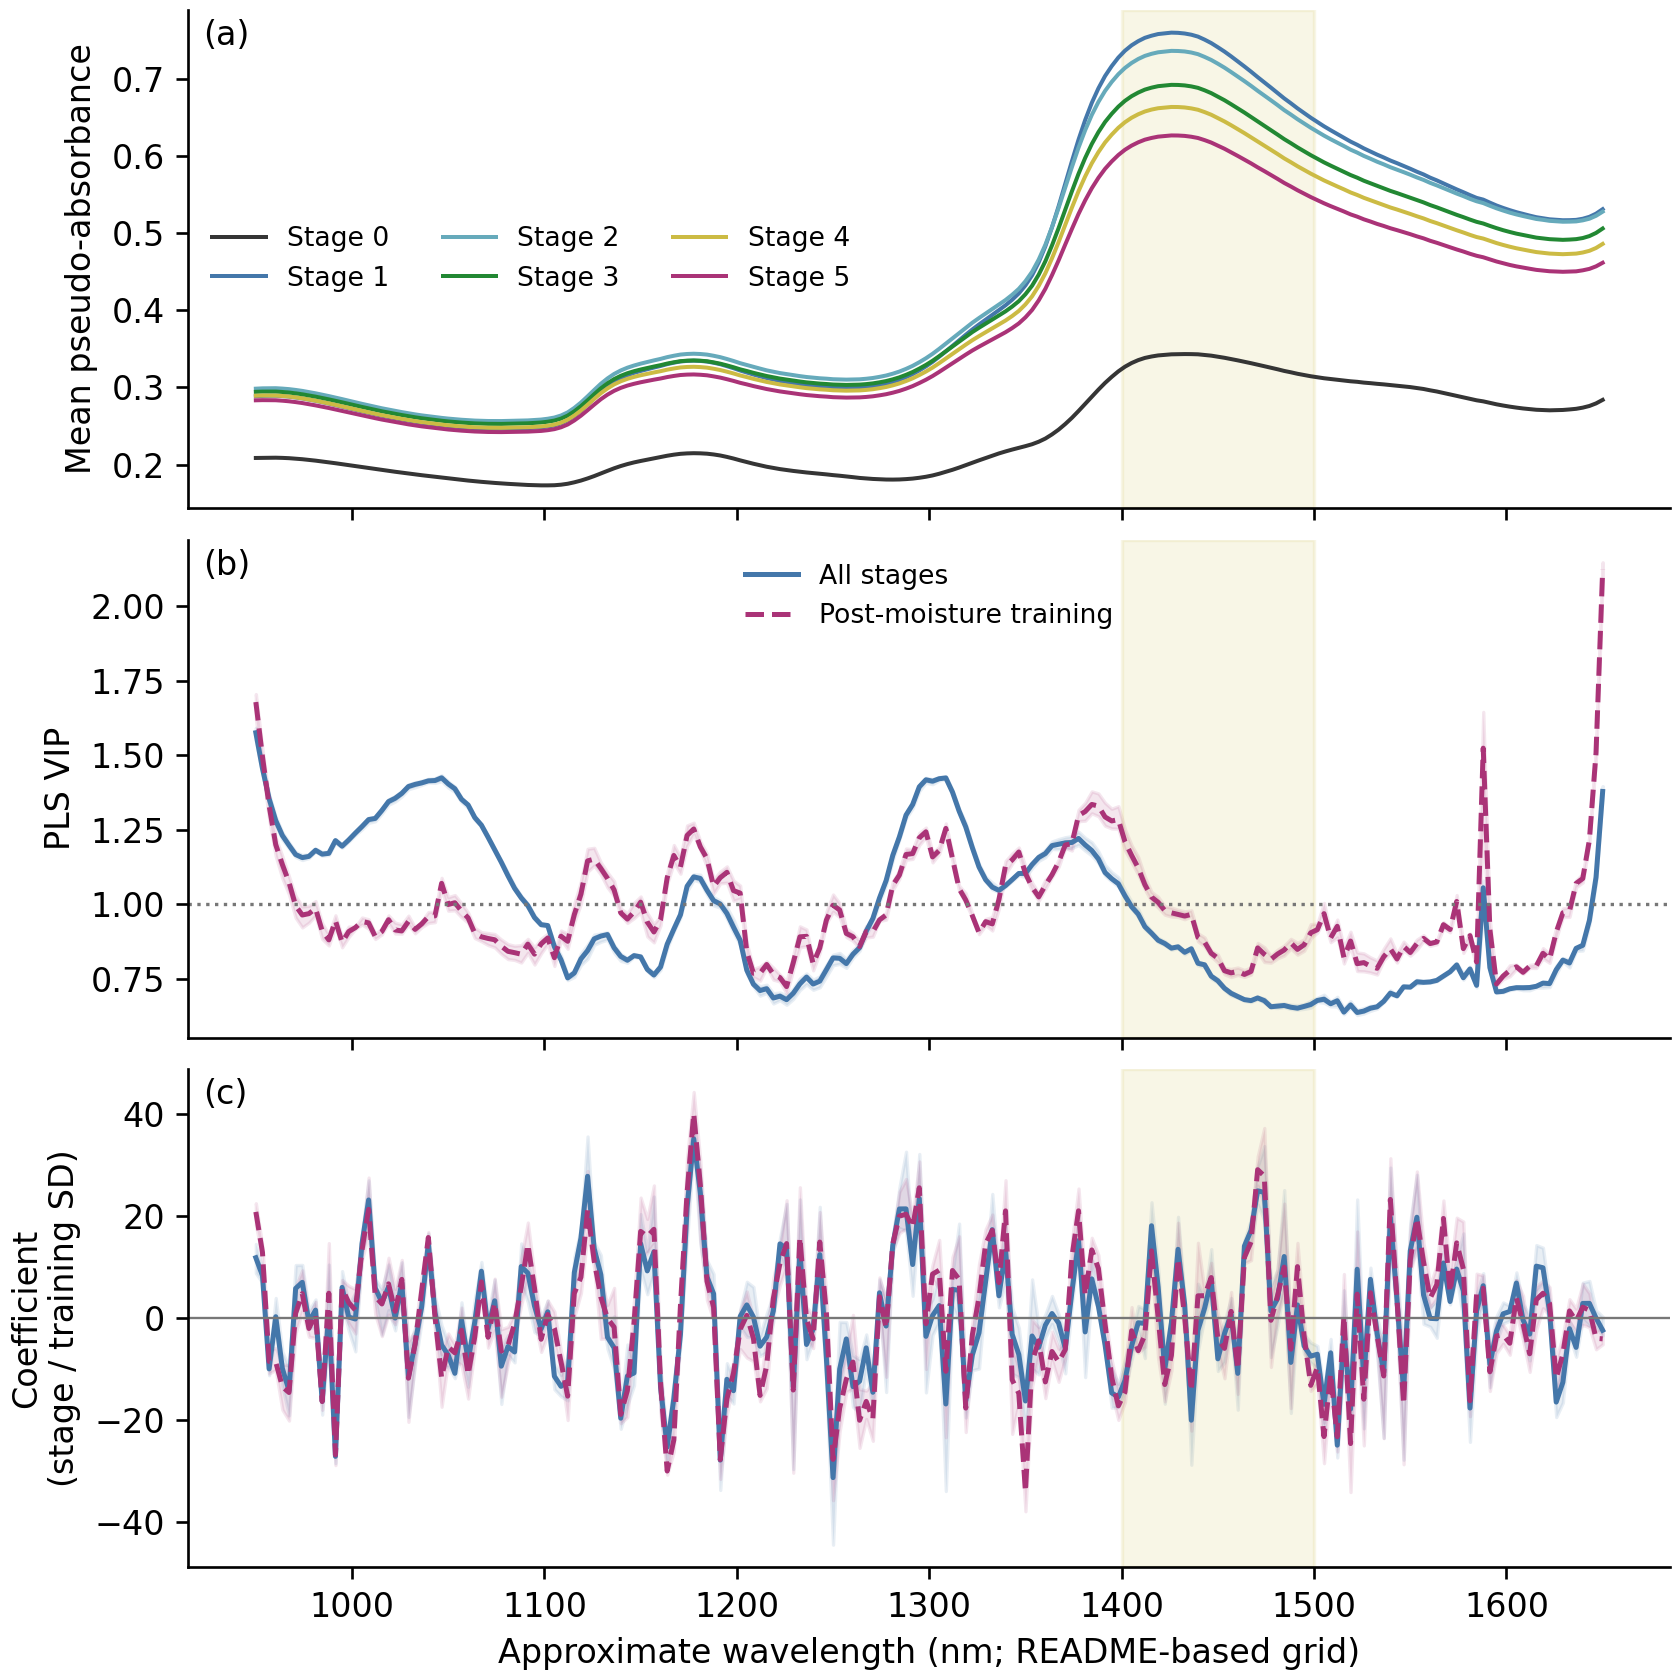

In [9]:
RUN_REVIEW_DIAGNOSTICS = False
REVIEW_DIR = RESULTS_DIR / 'revision_r1'
if RUN_REVIEW_DIAGNOSTICS:
    import sys
    sys.path.insert(0, str(CODE_FILE.parent))
    from run_review_additions import main as run_review
    run_review(PROJECT_DIR)

review = json.loads((REVIEW_DIR / 'review_additions_audit.json').read_text())
assert review['result'] == 'passed'
assert review['primary_predictions_unchanged']
assert not review['external_diagnostic_model_selection']
assert review['primary_oof_sha256'] == hashlib.sha256(
    (RESULTS_DIR / 'nested_oof_predictions.csv.gz').read_bytes()).hexdigest()
profiles = pd.read_csv(REVIEW_DIR / 'pls_training_profiles.csv')
assert len(profiles) == 5 * 2 * 204
for (_, _), profile in profiles.groupby(['outer_fold', 'training_subset']):
    assert len(profile) == 204
    np.testing.assert_allclose(np.mean(profile.vip.to_numpy() ** 2), 1, atol=1e-10)
display(pd.read_csv(REVIEW_DIR / 'diagnostics_split_audit.csv'))
bands = pd.read_csv(REVIEW_DIR / 'pls_band_summaries.csv')
display(bands.loc[bands.band_nm_approx.eq('1400-1500')].round(4))
display(Image(filename=str(REVIEW_DIR / 'fig_spectral_interpretation.png')))
print('Perfiles supervisados de entrenamiento; banda O–H compatible, no prueba causal.')

In [10]:
frozen = pd.read_csv(REVIEW_DIR / 'svr_frozen_C_predictions.csv.gz')
reported = pd.read_csv(REVIEW_DIR / 'svr_frozen_C_summary.csv')
assert set(frozen.C.unique()) == {100, 300, 1000}
for c_value, frame in frozen.groupby('C'):
    assert len(frame) == len(y) and frame.row_index.nunique() == len(y)
    for subset, values in [('all_six_stages', frame),
                           ('post_moisture_1_to_5', frame.loc[frame.y_true.ge(1)])]:
        expected = reported.loc[reported.C.eq(c_value) & reported.subset.eq(subset)].iloc[0]
        actual = metrics(values, values.y_pred)
        for name in ['mae', 'rmse', 'r2']:
            np.testing.assert_allclose(actual[name], expected[name], atol=1e-10)
baseline = frozen.loc[frozen.C.eq(100)].sort_values('row_index')
original = best.sort_values('row_index')
np.testing.assert_allclose(baseline.y_pred, original.y_pred, atol=1e-12)
display(reported.round(5))
display(pd.read_csv(REVIEW_DIR / 'svr_frozen_C_fold_metrics.csv').round(5))
print('Todos los C se reportan; los errores externos no seleccionan el modelo principal.')

   C               subset     n     mae    rmse      r2  within_1_day     bias  all_stage_fold_mae_sd
 100       all_six_stages 13452 0.57696 0.79994 0.78060       0.80256 -0.01531                0.01022
 100 post_moisture_1_to_5 11210 0.68000 0.87451 0.61762       0.76343 -0.01962                0.01022
 300       all_six_stages 13452 0.58976 0.82271 0.76794       0.80100 -0.00540                0.01259
 300 post_moisture_1_to_5 11210 0.69170 0.89801 0.59679       0.76173 -0.00813                0.01259
1000       all_six_stages 13452 0.61940 0.88724 0.73010       0.79312 -0.00081                0.02061
1000 post_moisture_1_to_5 11210 0.72130 0.96680 0.53264       0.75245 -0.00276                0.02061
 outer_fold    C preprocessing  epsilon gamma     mae    rmse      r2  within_1_day     bias
          1  100           snv     0.05 scale 0.58013 0.80786 0.77624       0.79993  0.02215
          1  300           snv     0.05 scale 0.58049 0.80920 0.77550       0.80327  0.02943
       

## 7 Alcance y pendientes de envío

- Son resultados de un experimento público y dos cultivares, no de una cosecha o instrumento externos.
- Etapa y sesión coinciden en una secuencia. No se puede descartar fingerprinting de sesión en vez de progreso biológico; separar placas y calcular VIP no lo resuelve.
- La referencia 0 es seca y anterior a la humectación; no valida una trayectoria continua desde el instante exacto de humectación.
- El pegamento afectó la germinación en el experimento de origen. No se utiliza este modelo para decidir viabilidad de semillas.
- El bootstrap describe incertidumbre condicional de errores guardados; no incluye reajuste completo ni selección de familia.
- El aporte es un benchmark reproducible con objetivo y límites explícitos; no un algoritmo nuevo ni una certificación de uso industrial.

Revise el manuscrito y los metadatos de la corrida antes de trasladar números a la ponencia. La autoría, afiliación y declaración de asistencia de IA deben completarse y revisarse por los autores.

Resultado central para interpretar la dificultad: MAE post-humedad = 0,680 y R² = 0,618. El agregado de seis etapas es 0,577 y R² = 0,781. La diferencia fila–placa de 0,021 es pequeña y no constituye una prueba de equivalencia.

Antes del envío: confirmar nombres, orden, afiliaciones, roles CRediT, financiamiento y conflictos; publicar el depósito aprobado y verificar el DOI. Este notebook no publica ni envía archivos.